<a href="https://colab.research.google.com/github/AnanyaTyagi/BrainMetShare-3-Benchmarking/blob/main/Brain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install nibabel monai torchmetrics

import os, glob, math, random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F


from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import Resize
from torchmetrics.classification import BinaryPrecision, BinaryRecall, BinaryAccuracy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 148.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 94.9 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
from google.colab import drive
OUT_DIR = "/content/output_brainmets"
os.makedirs(OUT_DIR, exist_ok=True)

drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/brainmetshare-3"
TRAIN_DIR = f"{DATA_DIR}/train"
TEST_DIR  = f"{DATA_DIR}/test"
print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists :", os.path.exists(TEST_DIR))

def check_split(split_dir, max_cases=5):
    cases = sorted([p for p in glob.glob(os.path.join(split_dir, "*")) if os.path.isdir(p)])
    print(f"\n{split_dir} cases:", len(cases))
    need = ["bravo.nii.gz", "flair.nii.gz", "t1_gd.nii.gz", "t1_pre.nii.gz", "seg.nii.gz"]
    for c in cases[:max_cases]:
        missing = [f for f in need if not os.path.exists(os.path.join(c, f))]
        print(os.path.basename(c), "OK" if not missing else f"Missing: {missing}")

check_split(TRAIN_DIR)
check_split(TEST_DIR)

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-5


Mounted at /content/drive
Train dir exists: True
Test dir exists : True

/content/drive/MyDrive/brainmetshare-3/train cases: 105
Mets_005 OK
Mets_010 OK
Mets_011 OK
Mets_013 OK
Mets_014 OK

/content/drive/MyDrive/brainmetshare-3/test cases: 51
Mets_009 Missing: ['seg.nii.gz']
Mets_021 Missing: ['seg.nii.gz']
Mets_025 Missing: ['seg.nii.gz']
Mets_029 Missing: ['seg.nii.gz']
Mets_038 Missing: ['seg.nii.gz']


All test cases: 51
Complete test cases: 50
Skipped incomplete: 1
SKIP: Mets_307 missing: ['flair.nii.gz']
Train cases: 105
Test cases : 50
Train split: 90
Val split  : 15
Train samples: 8705
Val samples  : 2250
Test slices  : 7500
Epoch 01/20 | Loss 1.3185 | Val Dice 0.0000 | P 0.0000 R 0.0000 Acc 0.9994
Epoch 02/20 | Loss 0.9236 | Val Dice 0.0000 | P 0.0000 R 0.0000 Acc 0.9994
Epoch 03/20 | Loss 0.8184 | Val Dice 0.4679 | P 0.6469 R 0.4785 Acc 0.9995
Epoch 04/20 | Loss 0.7574 | Val Dice 0.5644 | P 0.4901 R 0.5837 Acc 0.9994
Epoch 05/20 | Loss 0.7129 | Val Dice 0.5227 | P 0.5032 R 0.5056 Acc 0.9994
Epoch 06/20 | Loss 0.6885 | Val Dice 0.5945 | P 0.5167 R 0.6530 Acc 0.9994
Epoch 07/20 | Loss 0.6632 | Val Dice 0.5657 | P 0.4381 R 0.6036 Acc 0.9993
Epoch 08/20 | Loss 0.6510 | Val Dice 0.6010 | P 0.5116 R 0.6580 Acc 0.9994
Epoch 09/20 | Loss 0.6408 | Val Dice 0.6038 | P 0.4771 R 0.6171 Acc 0.9993
Epoch 10/20 | Loss nan | Val Dice 0.5788 | P 0.5082 R 0.5499 Acc 0.9994
Epoch 11/20 | Loss 0.6

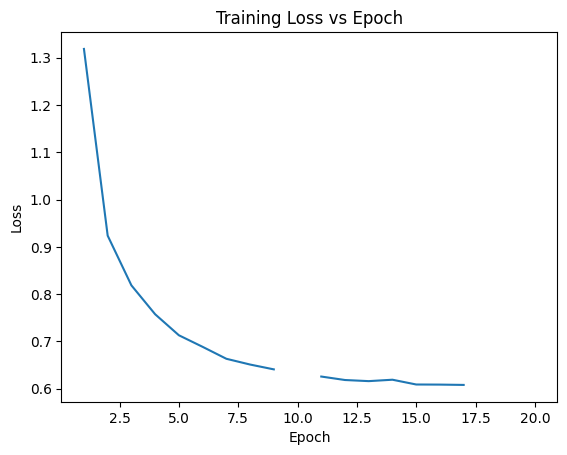

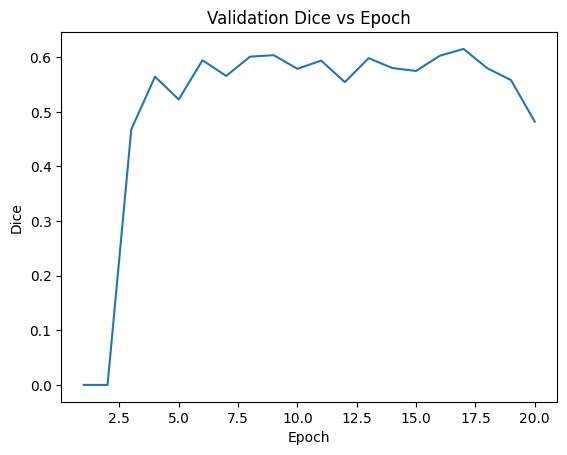

Saved test predictions to: /content/output_brainmets/test_predictions
Example case: Mets_232


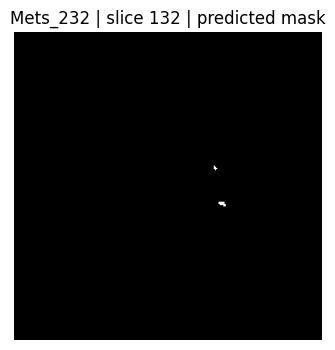

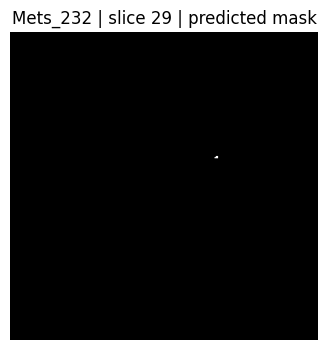

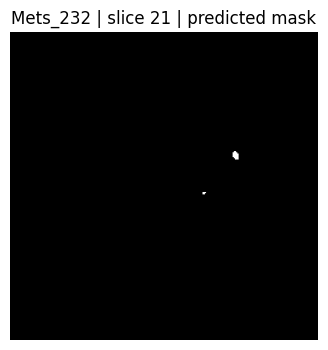


===== FINAL VALIDATION METRICS (REPORT THESE) =====
Dice      : 0.6152
Precision : 0.5216
Recall    : 0.5892
Accuracy  : 0.9994


In [4]:
def load_nii(path: str) -> np.ndarray:
    return np.asarray(nib.load(path).get_fdata(), dtype=np.float32)

def normalize_volume(vol: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    v = vol.copy()
    lo, hi = np.percentile(v, 1.0), np.percentile(v, 99.0)
    v = np.clip(v, lo, hi)
    v = (v - v.min()) / (v.max() - v.min() + eps)
    return v

def find_cases(split_dir: str):
    cases = sorted([p for p in glob.glob(os.path.join(split_dir, "*")) if os.path.isdir(p)])
    if len(cases) == 0:
        raise FileNotFoundError(f"No case folders found in: {split_dir}")
    return cases

train_cases_all = find_cases(TRAIN_DIR)
test_cases = find_cases(TEST_DIR)


REQUIRED_TEST_FILES = ["t1_pre.nii.gz", "t1_gd.nii.gz", "bravo.nii.gz", "flair.nii.gz"]

def filter_complete_cases(cases):
    good, bad = [], []
    for c in cases:
        missing = [f for f in REQUIRED_TEST_FILES if not os.path.exists(os.path.join(c, f))]
        if missing:
            bad.append((c, missing))
        else:
            good.append(c)
    return good, bad

test_cases_all = test_cases  # keep original list
test_cases, bad_cases = filter_complete_cases(test_cases_all)

print("All test cases:", len(test_cases_all))
print("Complete test cases:", len(test_cases))
print("Skipped incomplete:", len(bad_cases))
for c, miss in bad_cases[:10]:
    print("SKIP:", os.path.basename(c), "missing:", miss)

print("Train cases:", len(train_cases_all))
print("Test cases :", len(test_cases))

# ------------------ TRAIN/VAL SPLIT (from train only) ------------------
random.shuffle(train_cases_all)
val_frac = 0.15
n_val = max(1, int(len(train_cases_all) * val_frac))
val_cases = train_cases_all[:n_val]
train_cases = train_cases_all[n_val:]

print("Train split:", len(train_cases))
print("Val split  :", len(val_cases))
IMAGE_SIZE = (256, 256)

class BrainMets2DSliceDatasetWithMask(Dataset):
    """
    For TRAIN/VAL: Requires seg.nii.gz
    Produces (x: 4xHxW, y: 1xHxW)
    """
    def __init__(self, cases, image_size=(256,256), training=True, oversample_pos=0.5, max_slices_per_case=96):
        self.cases = cases
        self.training = training
        self.oversample_pos = oversample_pos

        self.resize_img = Resize(spatial_size=image_size, mode="bilinear")
        self.resize_msk = Resize(spatial_size=image_size, mode="nearest")

        self.case_slices = []
        self._cache = {}

        for c in self.cases:
            seg_path = os.path.join(c, "seg.nii.gz")
            if not os.path.exists(seg_path):
                raise FileNotFoundError(f"Missing seg.nii.gz in {c}")

            seg = load_nii(seg_path)
            D = seg.shape[-1]
            all_idx = list(range(D))
            pos_idx = [i for i in all_idx if np.any(seg[..., i] > 0.5)]

            if max_slices_per_case is not None and D > max_slices_per_case:
                keep_pos = pos_idx
                remaining = [i for i in all_idx if i not in set(keep_pos)]
                k = max(0, max_slices_per_case - len(keep_pos))
                keep_neg = random.sample(remaining, k=min(k, len(remaining)))
                all_idx = sorted(list(set(keep_pos + keep_neg)))
                pos_idx = sorted([i for i in all_idx if i in set(keep_pos)])

            self.case_slices.append({"case": c, "all": all_idx, "pos": pos_idx})

        self.length = sum(len(x["all"]) for x in self.case_slices)

    def __len__(self):
        return self.length

    def _load_case(self, case_path):
        if case_path in self._cache:
            return self._cache[case_path]

        paths = {
            "t1_pre": os.path.join(case_path, "t1_pre.nii.gz"),
            "t1_gd":  os.path.join(case_path, "t1_gd.nii.gz"),
            "flair":  os.path.join(case_path, "flair.nii.gz"),
            "bravo":  os.path.join(case_path, "bravo.nii.gz"),
            "seg":    os.path.join(case_path, "seg.nii.gz"),
        }
        for k,p in paths.items():
            if not os.path.exists(p):
                raise FileNotFoundError(f"Missing {k} in {case_path}")

        t1_pre = normalize_volume(load_nii(paths["t1_pre"]))
        t1_gd  = normalize_volume(load_nii(paths["t1_gd"]))
        flair  = normalize_volume(load_nii(paths["flair"]))
        bravo  = normalize_volume(load_nii(paths["bravo"]))
        seg    = (load_nii(paths["seg"]) > 0.5).astype(np.float32)

        if not (t1_pre.shape == t1_gd.shape == flair.shape == bravo.shape == seg.shape):
            raise ValueError(f"Shape mismatch in {case_path}")

        self._cache[case_path] = (t1_pre, t1_gd, flair, bravo, seg)
        return self._cache[case_path]

    def __getitem__(self, idx):
        running = 0
        for info in self.case_slices:
            n = len(info["all"])
            if idx < running + n:
                case_path = info["case"]
                local_idx = idx - running

                # choose slice
                if self.training and len(info["pos"]) > 0 and random.random() < self.oversample_pos:
                    z = random.choice(info["pos"])
                else:
                    z = info["all"][local_idx]

                t1_pre, t1_gd, flair, bravo, seg = self._load_case(case_path)

                x = np.stack([t1_pre[..., z], t1_gd[..., z], flair[..., z], bravo[..., z]], axis=0)
                y = seg[..., z][None, ...]

                x = torch.from_numpy(x)
                y = torch.from_numpy(y)

                x = x.squeeze()
                y = y.squeeze()

                if x.ndim == 2:  # just in case
                    x = x.unsqueeze(0)
                if y.ndim == 2:
                    y = y.unsqueeze(0)

                # resize safely
                x = F.interpolate(x.unsqueeze(0), size=IMAGE_SIZE, mode="bilinear", align_corners=False).squeeze(0)
                y = F.interpolate(y.unsqueeze(0), size=IMAGE_SIZE, mode="nearest").squeeze(0)


                # augmentation
                if self.training:
                    if random.random() < 0.5:
                        x = torch.flip(x, dims=[2]); y = torch.flip(y, dims=[2])
                    if random.random() < 0.5:
                        x = torch.flip(x, dims=[1]); y = torch.flip(y, dims=[1])
                    k = random.randint(0,3)
                    if k:
                        x = torch.rot90(x, k, dims=[1,2])
                        y = torch.rot90(y, k, dims=[1,2])

                return x, y
            running += n
        raise IndexError("Index out of range")

class BrainMets2DSliceDatasetNoMask(Dataset):
    """
    For TEST: No seg.nii.gz
    Returns (x, case_path, slice_index, original_shape)
    """
    def __init__(self, cases, image_size=(256,256)):
        self.cases = cases
        self.resize_img = Resize(spatial_size=image_size, mode="bilinear")

        self.index = []  # list of (case_path, z)
        self._cache = {}

        for c in self.cases:
            # determine slices from one modality
            ref_path = os.path.join(c, "t1_gd.nii.gz")
            if not os.path.exists(ref_path):
                raise FileNotFoundError(f"Missing t1_gd.nii.gz in {c}")
            ref = load_nii(ref_path)
            D = ref.shape[-1]
            for z in range(D):
                self.index.append((c, z))

    def __len__(self):
        return len(self.index)

    def _load_case(self, case_path):
        if case_path in self._cache:
            return self._cache[case_path]

        paths = {
            "t1_pre": os.path.join(case_path, "t1_pre.nii.gz"),
            "t1_gd":  os.path.join(case_path, "t1_gd.nii.gz"),
            "flair":  os.path.join(case_path, "flair.nii.gz"),
            "bravo":  os.path.join(case_path, "bravo.nii.gz"),
        }
        for k,p in paths.items():
            if not os.path.exists(p):
                raise FileNotFoundError(f"Missing {k} in {case_path}")

        t1_pre = normalize_volume(load_nii(paths["t1_pre"]))
        t1_gd  = normalize_volume(load_nii(paths["t1_gd"]))
        flair  = normalize_volume(load_nii(paths["flair"]))
        bravo  = normalize_volume(load_nii(paths["bravo"]))

        if not (t1_pre.shape == t1_gd.shape == flair.shape == bravo.shape):
            raise ValueError(f"Shape mismatch in {case_path}")

        self._cache[case_path] = (t1_pre, t1_gd, flair, bravo)
        return self._cache[case_path]

    import torch.nn.functional as F


    def __getitem__(self, idx):
        case_path, z = self.index[idx]
        t1_pre, t1_gd, flair, bravo = self._load_case(case_path)

        # Force 2D slices (H,W) no matter what
        s_t1_pre = np.squeeze(t1_pre[..., z])
        s_t1_gd  = np.squeeze(t1_gd[..., z])
        s_flair  = np.squeeze(flair[..., z])
        s_bravo  = np.squeeze(bravo[..., z])

        orig_shape = s_t1_gd.shape  # (H,W)

        x = np.stack([s_t1_pre, s_t1_gd, s_flair, s_bravo], axis=0)  # (4,H,W)
        x = torch.from_numpy(x).float()

        # Ensure (C,H,W)
        if x.ndim == 2:
           x = x.unsqueeze(0)

        # Safe resize
        x = F.interpolate(
        x.unsqueeze(0),
        size=IMAGE_SIZE,
        mode="bilinear",
        align_corners=False).squeeze(0)

        return x, case_path, int(z), orig_shape


# Loaders
train_ds = BrainMets2DSliceDatasetWithMask(train_cases, image_size=IMAGE_SIZE, training=True, oversample_pos=0.5, max_slices_per_case=96)
val_ds   = BrainMets2DSliceDatasetWithMask(val_cases,   image_size=IMAGE_SIZE, training=False, oversample_pos=0.0, max_slices_per_case=None)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

test_ds = BrainMets2DSliceDatasetNoMask(test_cases, image_size=IMAGE_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


#test_ds = BrainMets2DSliceDatasetNoMask(test_cases, image_size=IMAGE_SIZE)
#test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


print("Train samples:", len(train_ds))
print("Val samples  :", len(val_ds))
print("Test slices  :", len(test_ds))

#MODEL

model = UNet(
    spatial_dims=2,
    in_channels=4,
    out_channels=1,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

criterion = DiceCELoss(sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

dice_metric = DiceMetric(include_background=True, reduction="mean")
precision_metric = BinaryPrecision(threshold=0.5).to(device)
recall_metric    = BinaryRecall(threshold=0.5).to(device)
acc_metric       = BinaryAccuracy(threshold=0.5).to(device)

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

def evaluate_seg(model, loader):
    model.eval()
    dice_metric.reset()
    precision_metric.reset()
    recall_metric.reset()
    acc_metric.reset()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            dice_metric(y_pred=preds, y=y)

            precision_metric.update(preds.view(-1), y.view(-1))
            recall_metric.update(preds.view(-1), y.view(-1))
            acc_metric.update(preds.view(-1), y.view(-1))

    return (
        dice_metric.aggregate().item(),
        precision_metric.compute().item(),
        recall_metric.compute().item(),
        acc_metric.compute().item()
    )

#Train Loop

history = {"train_loss": [], "val_dice": [], "val_precision": [], "val_recall": [], "val_acc": []}
best_dice = -1

for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    n = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        n += 1

    train_loss = running / max(1, n)
    val_dice, val_p, val_r, val_a = evaluate_seg(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_dice"].append(val_dice)
    history["val_precision"].append(val_p)
    history["val_recall"].append(val_r)
    history["val_acc"].append(val_a)

    print(f"Epoch {epoch:02d}/{EPOCHS} | Loss {train_loss:.4f} | Val Dice {val_dice:.4f} | P {val_p:.4f} R {val_r:.4f} Acc {val_a:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), os.path.join(OUT_DIR, "best_unet.pth"))

print("Best model saved:", os.path.join(OUT_DIR, "best_unet.pth"))

#PLOTS
plt.figure()
plt.plot(range(1, EPOCHS+1), history["train_loss"])
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training Loss vs Epoch")
plt.show()

plt.figure()
plt.plot(range(1, EPOCHS+1), history["val_dice"])
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Validation Dice vs Epoch")
plt.show()


#INFERENCE ON TEST
best_model = UNet(
    spatial_dims=2,
    in_channels=4,
    out_channels=1,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)
best_model.load_state_dict(torch.load(os.path.join(OUT_DIR, "best_unet.pth"), map_location=device))
best_model.eval()

# We’ll reconstruct per-case 3D predictions and save as NIfTI
from collections import defaultdict
pred_store = defaultdict(list)  # case -> list of (z, pred_2d_array, orig_shape)

with torch.no_grad():
    for x, case_path, z, orig_shape in test_loader:
        x = x.to(device)
        logits = best_model(x)
        probs = torch.sigmoid(logits).cpu().numpy()  # (B,1,H,W)

        # Safely convert batch elements
        case_list = list(case_path)
        z_list = [int(v) for v in z]
        orig_list = list(orig_shape)

        for case, zi, prob_map, osh in zip(case_list, z_list, probs[:, 0], orig_list):
            pred2d = (prob_map >= 0.5).astype(np.uint8)
            pred_store[case].append((zi, pred2d, osh))


# Save per case
save_dir = os.path.join(OUT_DIR, "test_predictions")
os.makedirs(save_dir, exist_ok=True)

for case, items in pred_store.items():
    items = sorted(items, key=lambda t: t[0])  # sort by slice index
    # Determine original H,W,D using a reference modality
    ref_path = os.path.join(case, "t1_gd.nii.gz")
    ref_img = nib.load(ref_path)
    ref = ref_img.get_fdata()
    H, W, D = ref.shape

    # Build volume in resized space first (256,256,D)
    vol_resized = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], D), dtype=np.uint8)
    for zi, pred2d, _ in items:
        vol_resized[..., zi] = pred2d

    # Optional: you can keep resized masks; or resize back to original (H,W)
    # Here we keep resized masks because it’s consistent + simple.
    out_nii = nib.Nifti1Image(vol_resized, affine=ref_img.affine)
    case_name = os.path.basename(case)
    out_path = os.path.join(save_dir, f"{case_name}_pred_seg_resized.nii.gz")
    nib.save(out_nii, out_path)

print("Saved test predictions to:", save_dir)

import random
some_case = random.choice(list(pred_store.keys()))
print("Example case:", os.path.basename(some_case))

# display 3 random slices from that case
items = sorted(pred_store[some_case], key=lambda t: t[0])
for zi, pred2d, _ in random.sample(items, k=min(3, len(items))):
    plt.figure(figsize=(4,4))
    plt.imshow(pred2d, cmap="gray")
    plt.title(f"{os.path.basename(some_case)} | slice {zi} | predicted mask")
    plt.axis("off")
    plt.show()

# ------------------ FINAL VAL METRICS FOR REPORT ------------------
val_dice, val_p, val_r, val_a = evaluate_seg(best_model, val_loader)
print("\n===== FINAL VALIDATION METRICS =====")
print(f"Dice      : {val_dice:.4f}")
print(f"Precision : {val_p:.4f}")
print(f"Recall    : {val_r:.4f}")
print(f"Accuracy  : {val_a:.4f}")


